In [1]:
import pandas as pd
import numpy as np
import torch

In [2]:
data = open('names.txt', 'r').read().split()

# DATA DISCOVERY

In [3]:
# DATA DISCOVERY

In [4]:
data[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
stoi = {s:i for i,s in enumerate(sorted(list(set(''.join(data)))))}
stoi['<s>'] = 26
stoi['</s>'] = 27
itos = {i:s for s,i in stoi.items()}


In [6]:
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<s>',
 27: '</s>'}

In [7]:
N = torch.zeros([28,28], dtype=torch.int32)
for ele in data:
    wrd = ['<s>'] + list(ele) + ['</s>']
    

    for ch1,ch2 in zip(wrd,wrd[1:]):
        idx1,idx2 = stoi[ch1],stoi[ch2]
        N[idx1,idx2] += 1

In [8]:
# sorted(N.items(), key=lambda kv: -kv[1])
# N

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bigram_matrix(
    N,
    itos,
    *,
    figsize=(12, 12),
    cmap='Blues',
    bigram_fontsize=8,
    count_fontsize=6,
    bigram_color='grey',
    count_color='grey',
    show=True,
):
    """
    Plot a bigram matrix with bigram labels on top and counts on the bottom.

    Parameters
    ----------
    N : array‑like (shape (n, n))
        Matrix of bigram counts.
    itos : dict or list
        Mapping from index → character.  If it is a list, the index is
        assumed to be the list index.
    figsize : tuple of float, optional
        Size of the figure in inches.
    cmap : str or Colormap, optional
        Colormap for the heatmap.
    bigram_fontsize : int, optional
        Font size of the bigram labels.
    count_fontsize : int, optional
        Font size of the count labels.
    bigram_color : str, optional
        Color of the bigram labels.
    count_color : str, optional
        Color of the count labels.
    show : bool, optional
        If ``True`` (default) the plot will be shown with
        ``plt.show()``.  If ``False`` the function returns the
        figure/axes objects.

    Returns
    -------
    fig, ax : matplotlib Figure, Axes
        Only returned when ``show=False``.
    """

    # Ensure we can index into `itos`
    if isinstance(itos, dict):
        words = [itos[i] for i in range(len(itos))]
    else:                 # assume list or tuple
        words = itos

    n = N.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(N, cmap=cmap)

    # Draw the text annotations
    for i in range(n):
        for j in range(n):
            bigram = f"{words[i]}{words[j]}"
            count  = N[i, j]
            # For Torch tensors: count.item()
            if hasattr(count, "item"):
                count = count.item()
            ax.text(j, i, bigram, ha='center', va='top',
                    fontsize=bigram_fontsize, color=bigram_color)
            # ax.text(j, i, str(count), ha='center', va='bottom',
            #         fontsize=count_fontsize, color=count_color)

            # New line – format to 2‑digit precision
            ax.text(j, i, f"{count:.2f}", ha='center', va='bottom',
                    fontsize=count_fontsize, color=count_color)

    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    if show:
        plt.show()
    else:
        return fig, ax

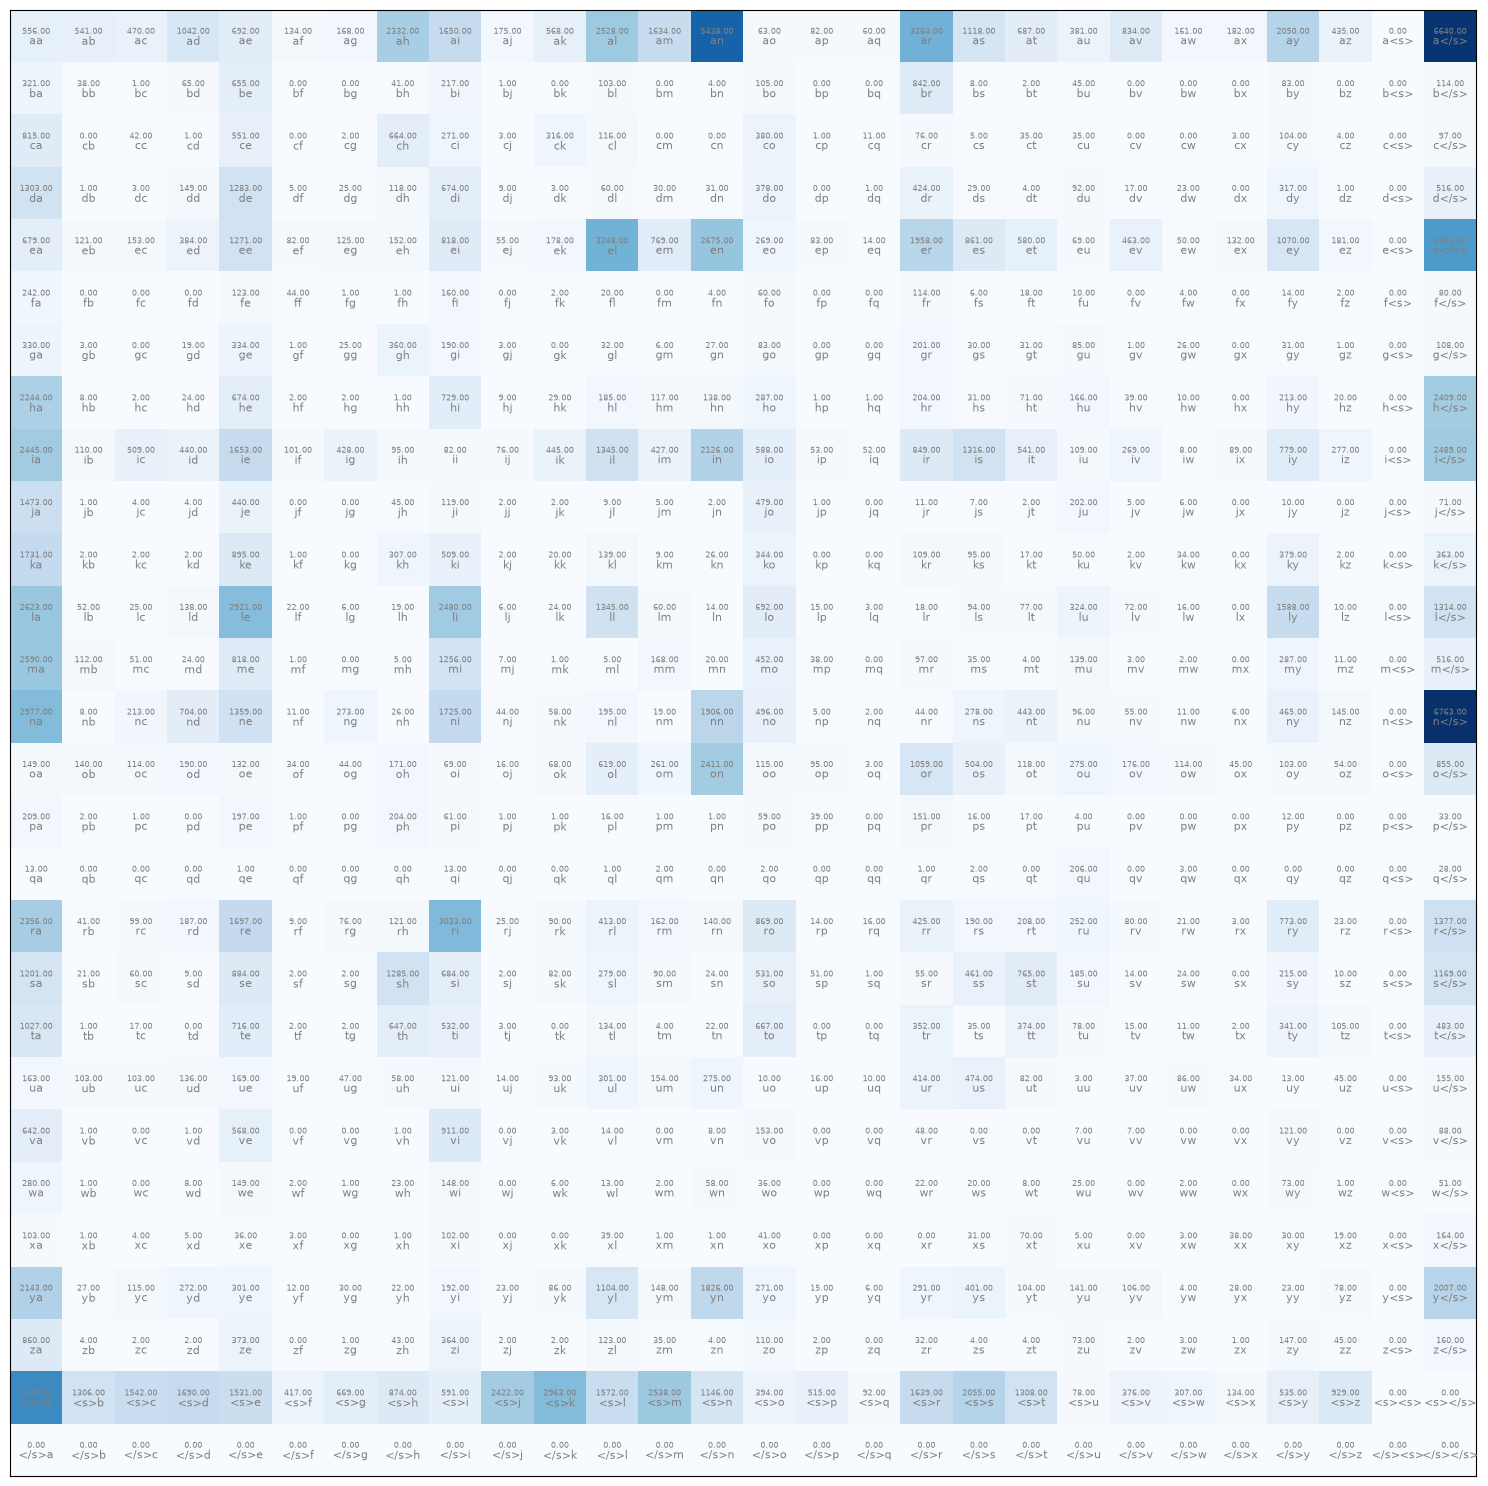

In [10]:
# Example: `N` is a 28×28 PyTorch tensor and `itos` is a dict mapping indices to characters
plot_bigram_matrix(N, itos, figsize=(15, 15), cmap='Blues')

In [11]:
stoi = {s:i + 1 for i,s in enumerate(sorted(list(set(''.join(data)))))}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}


N = torch.zeros([27,27], dtype=torch.int32)
for ele in data:
    wrd = ['.'] + list(ele) + ['.']
    

    for ch1,ch2 in zip(wrd,wrd[1:]):
        idx1,idx2 = stoi[ch1],stoi[ch2]
        N[idx1,idx2] += 1

In [12]:
# stoi

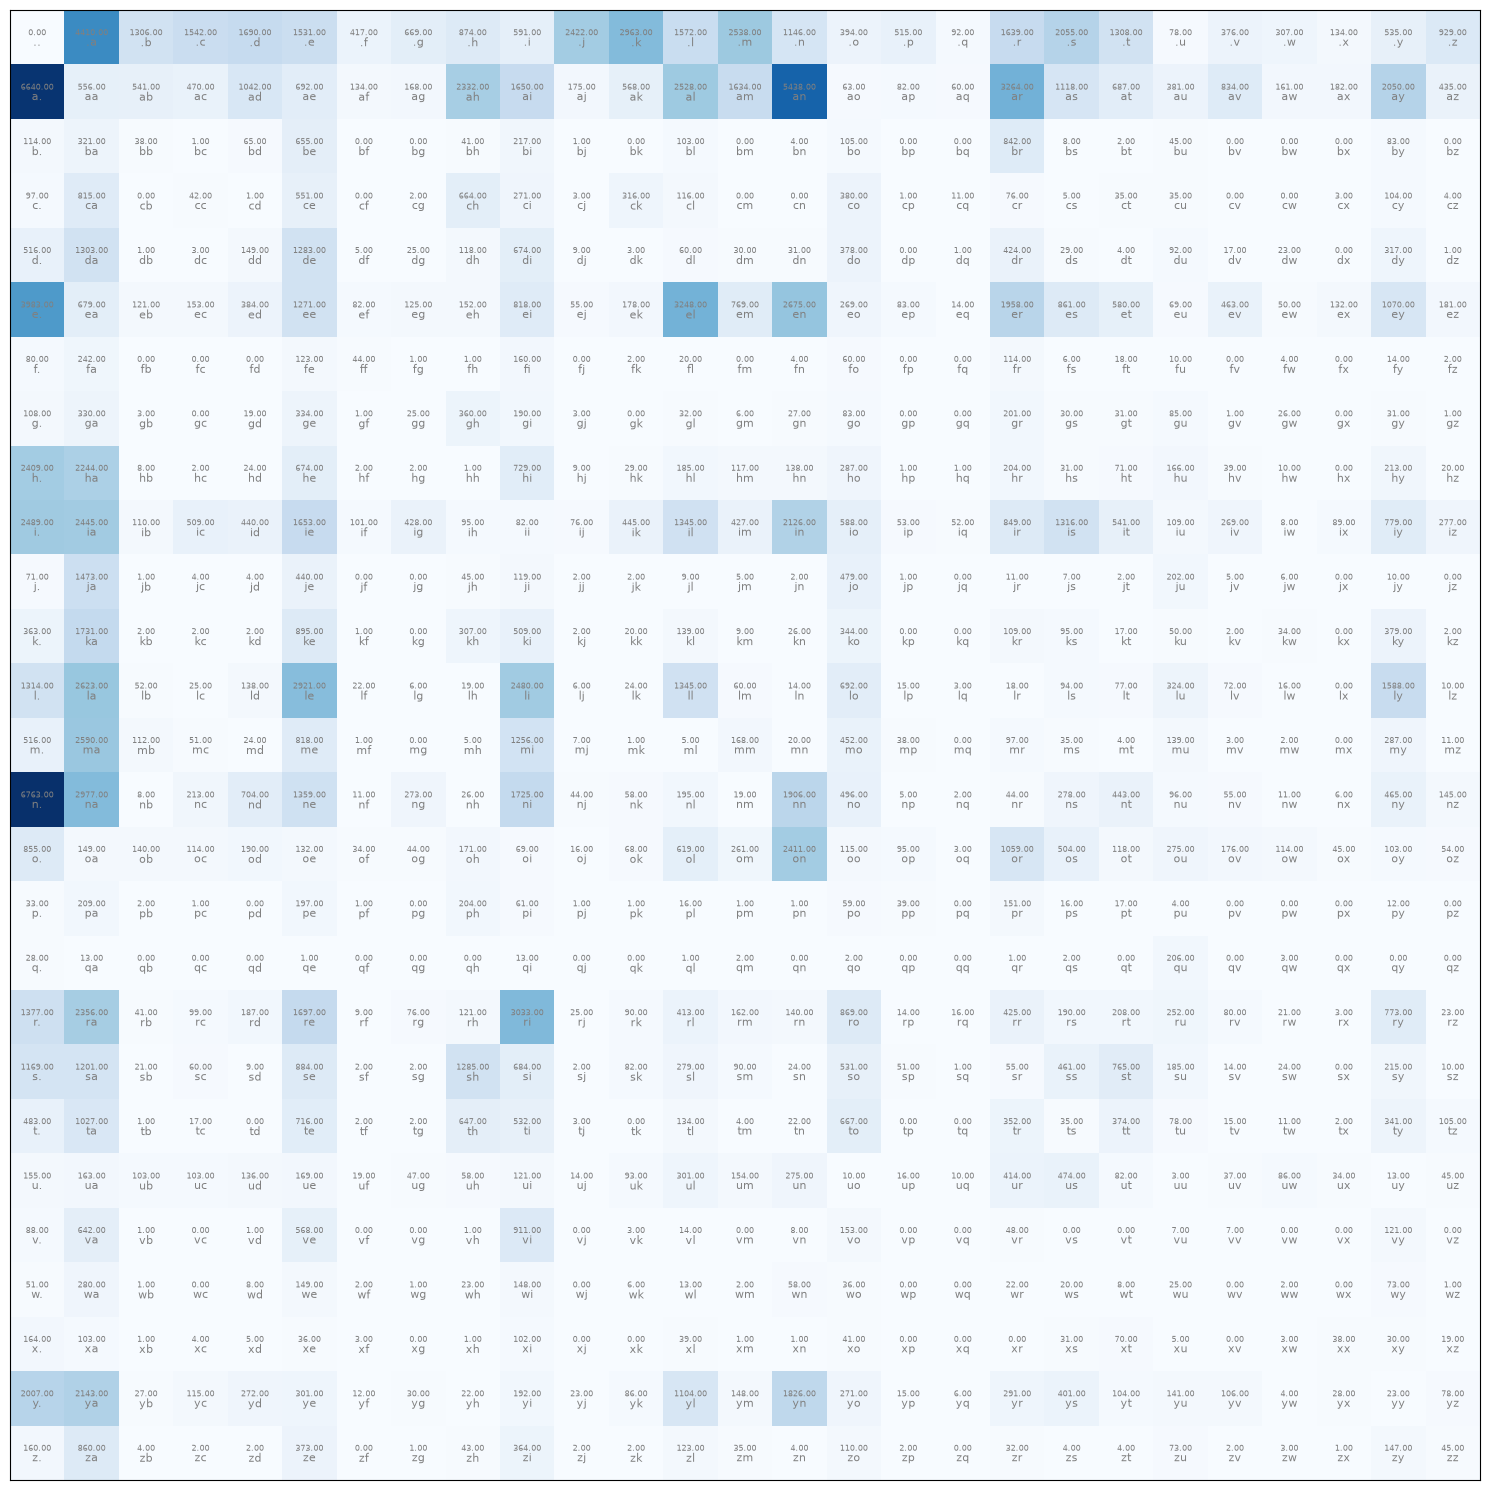

In [13]:
# Example: `N` is a 28×28 PyTorch tensor and `itos` is a dict mapping indices to characters
plot_bigram_matrix(N, itos, figsize=(15, 15), cmap='Blues')

In [14]:
P = N.float()
P /= P.sum(1, keepdim=True)

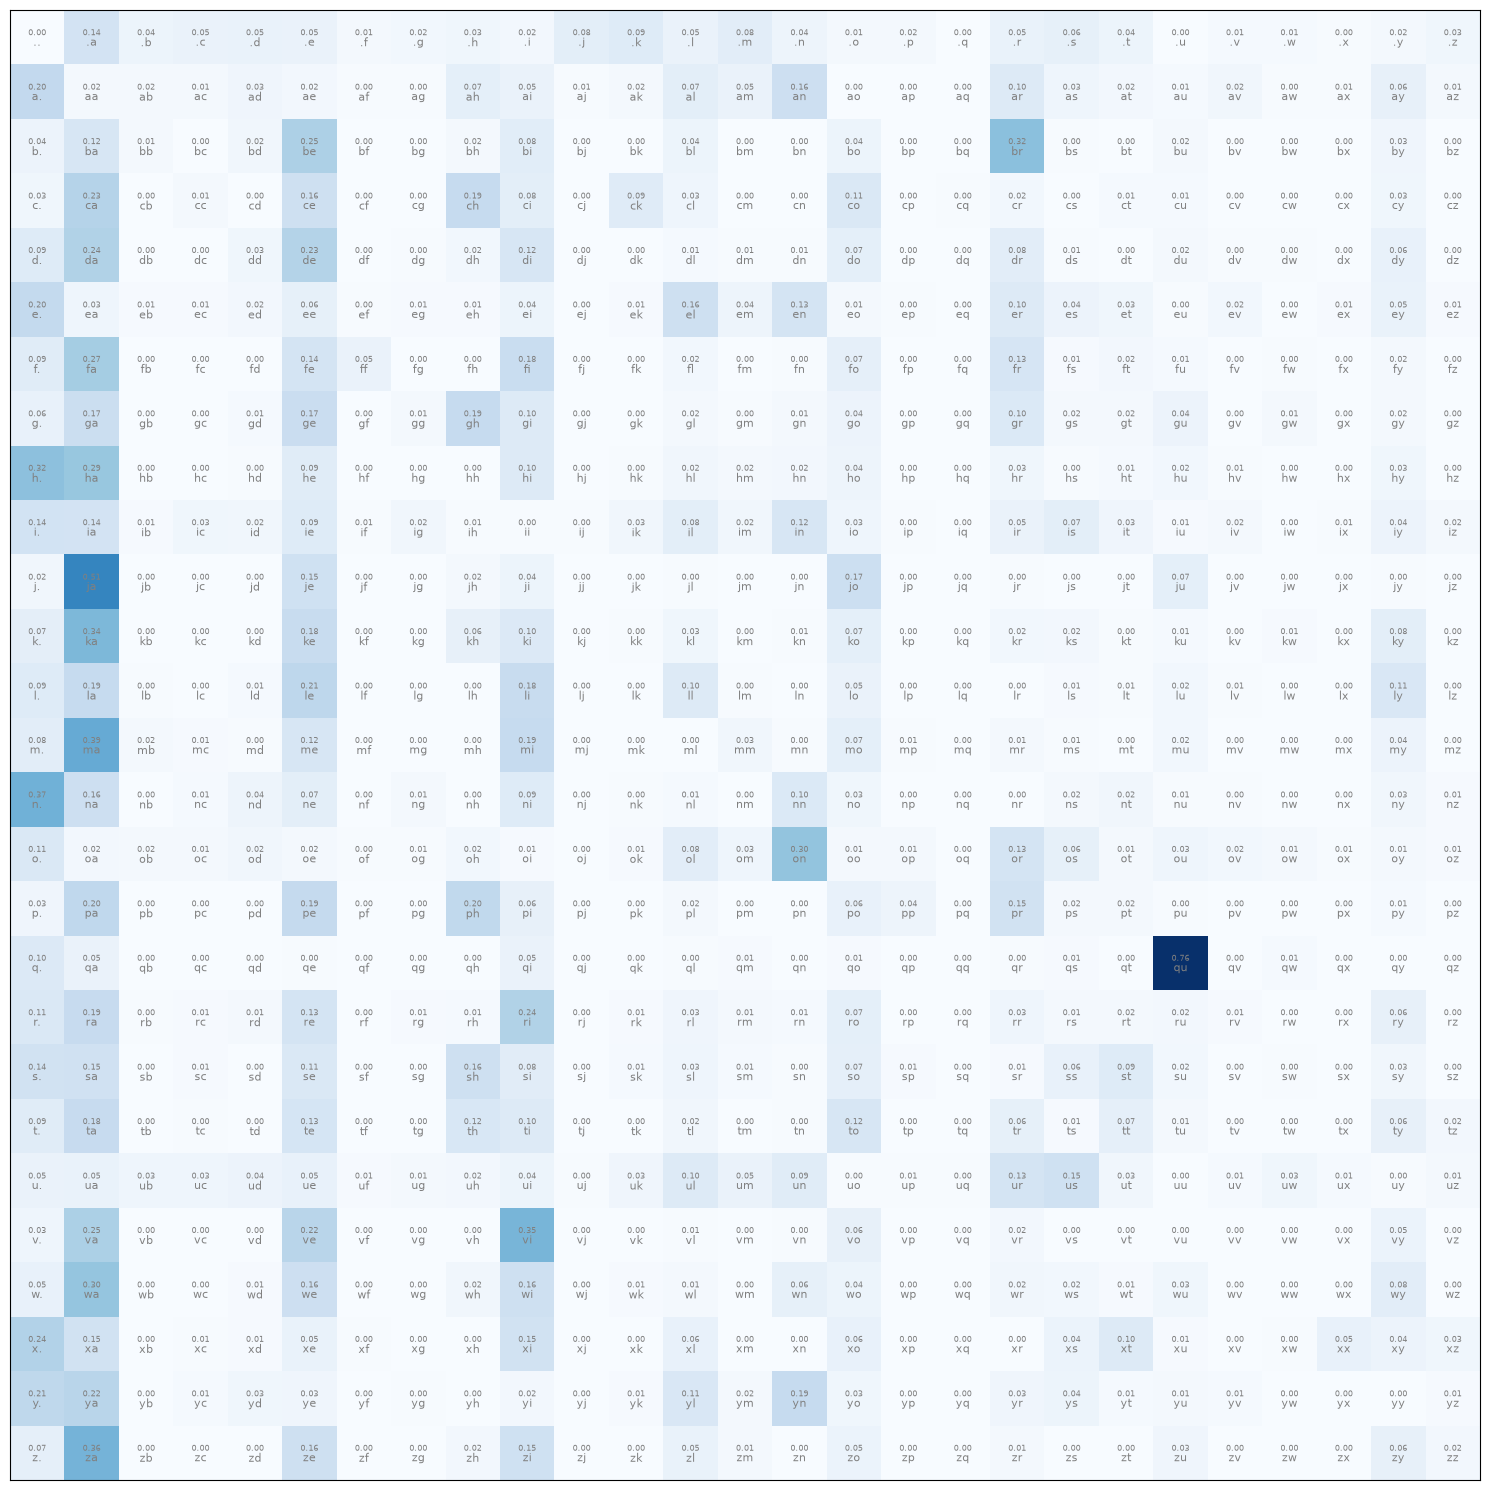

In [15]:
# Example: `N` is a 28×28 PyTorch tensor and `itos` is a dict mapping indices to characters
plot_bigram_matrix(P, itos, figsize=(15, 15), cmap='Blues')

# Un traned bi_gram

In [16]:
idx = 0
g = torch.Generator().manual_seed(2147483647)
genrations = 50
for _ in range(genrations):
    out = []
    uniform_probs = torch.ones(27, dtype=torch.float32) / 27.0
    while True:
        # uniform_probs  = torch.ones(27)/27.0
        idx = torch.multinomial(uniform_probs, 1, replacement=True,generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    print(''.join(out))

cexzm.
zoglkurkicqzktyhwmvmzimjttainrlkfukzkktda.
sfcxvpubjtbhrmgotzx.
iczixqctvujkwptedogkkjemkmmsidguenkbvgynywftbspmhwcivgbvtahlvsu.
dsdxxblnwglhpyiw.
igwnjwrpfdwipkwzkm.
desu.
firmt.
gbiksjbquabsvoth.
kuysxqevhcmrbxmcwyhrrjenvxmvpfkmwmghfvjzxobomysox.
gbptjapxweegpfwhccfyzfvksiiqmvwbhmiwqmdgzqsamjhgamcxwmmk.
iswcxfmbalcslhy.
fpycvasvz.
bqzazeunschck.
wnkojuoxyvtvfiwksddugnkul.
fuwfcgjz.
abl.
j.
nuuutstofgqzubbo.
rdubpknhmd.
vhfacdvaaasjzjkdh.
gh.
frdhlhahflrklmlcugro.
pnxhayx.
vn.
gixgosfqn.
mempfnclfxtirbqhvjfdwhzymayerzqvmzjvtjuifbooocnkcxjkvsmjafciekxoraw.
.
veigtbcaamnef.
chfeukwowgsadjjkkswrcpawhoxskfikwbscynndmiuxxwoturzhqnsjdndsziocnbxiegzzulhnqdqwosi.
kdwnfjvmtthtpzbmdvvrvtptaqlhdnkj.
zxkcbczsrcagitwicvkcqiotgnvpllciqs.
uohjxnvxqikebadkdawdfwwha.
fqcnmrpoljlpjldyjehpprjppsmkzdhrmgyoadmsod.
dnvzcobtzfikidecxjhbmmjxqphvtedjbwkxzhisndnoauiycrdfetifkvzlzf.
ud.
ckndsgyldqbkcylrozgwkjgftrahdrnfapspdayna.
thavpgelvlfqxxsdabgxpyzv.
ikzvrykvyxhuj.
qkpwzuaics.
xxqubplmqguhbpnetz.
.
t

# Traned bi_gram

In [17]:
idx = 0
g = torch.Generator().manual_seed(2147483647)
genrations = 50
for _ in range(genrations):
    out = []
    while True:
        idx = torch.multinomial(P[idx], 1, replacement=True,generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.
